
# Étape intermédiaire — Apprentissage non supervisé sur MNIST

Ce notebook applique **k-Means++**, **PCA** et un **autoencodeur simple** à un début du dataset MNIST.

Pour chaque algorithme :

- projection en faible dimension pour visualisation ;
- compression / décompression ;
- génération de données synthétiques.

Les labels MNIST sont utilisés uniquement pour interpréter certaines visualisations, jamais pour entraîner les algorithmes.


In [1]:

import os, random, time
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

SEED = 43
N_SAMPLES = 8000
K = 50
KMEANS_MAX_ITER = 30
KMEANS_TOL = 1e-4
PCA_COMPRESSION_COMPONENTS = 50
AE_EPOCHS = 100
BATCH_SIZE = 256

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print("TensorFlow :", tf.__version__)


TensorFlow : 2.20.0



# 1. Chargement et préparation de MNIST

Les pixels MNIST sont compris entre 0 et 255. Ils sont normalisés entre 0 et 1, puis chaque image 28 × 28 est transformée en un vecteur de 784 valeurs.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Images : (8000, 28, 28)
Vecteurs : (8000, 784)
Min / max : 0.0 1.0


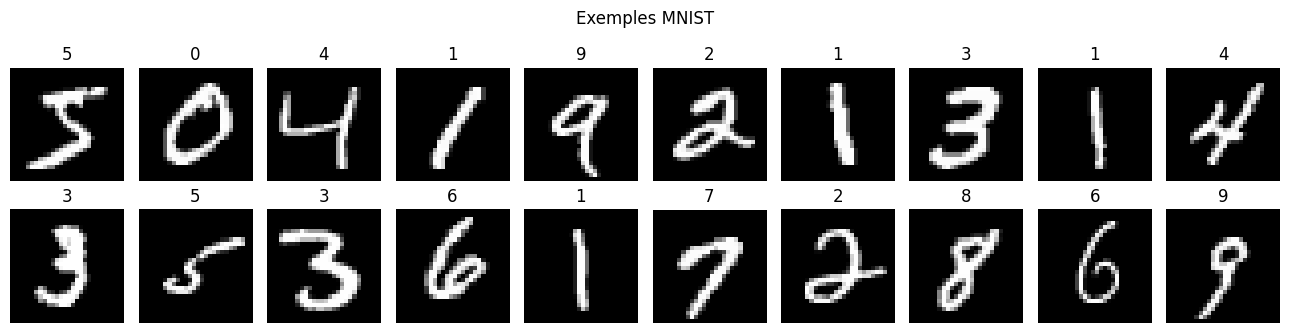

In [2]:

(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

X_images = X_train_full[:N_SAMPLES].astype(np.float32) / 255.0
y = y_train_full[:N_SAMPLES]
X_flat = X_images.reshape(N_SAMPLES, -1)

print("Images :", X_images.shape)
print("Vecteurs :", X_flat.shape)
print("Min / max :", X_flat.min(), X_flat.max())

fig, axes = plt.subplots(2, 10, figsize=(13, 3.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_images[i], cmap="gray")
    ax.set_title(str(y[i]))
    ax.axis("off")
plt.suptitle("Exemples MNIST")
plt.tight_layout()
plt.show()



# 2. k-Means avec initialisation k-Means++

k-Means regroupe les images autour de centroïdes. k-Means++ choisit des centroïdes initiaux mieux répartis qu’un choix entièrement aléatoire.


Itération 01 | inertie=410288.81 | déplacement=32.151012
Itération 02 | inertie=257673.88 | déplacement=6.981026
Itération 03 | inertie=248309.34 | déplacement=3.912848
Itération 04 | inertie=245140.44 | déplacement=2.935727
Itération 05 | inertie=243372.56 | déplacement=2.480020
Itération 06 | inertie=242192.19 | déplacement=1.773926
Itération 07 | inertie=241501.66 | déplacement=1.485988
Itération 08 | inertie=240997.38 | déplacement=1.254618
Itération 09 | inertie=240645.56 | déplacement=1.026171
Itération 10 | inertie=240403.06 | déplacement=0.994252
Itération 11 | inertie=240199.94 | déplacement=0.817179
Itération 12 | inertie=240066.11 | déplacement=0.785052
Itération 13 | inertie=239942.78 | déplacement=0.724979
Itération 14 | inertie=239842.17 | déplacement=0.510863
Itération 15 | inertie=239779.22 | déplacement=0.526013
Itération 16 | inertie=239720.95 | déplacement=0.448330
Itération 17 | inertie=239676.75 | déplacement=0.415621
Itération 18 | inertie=239636.09 | déplacement=

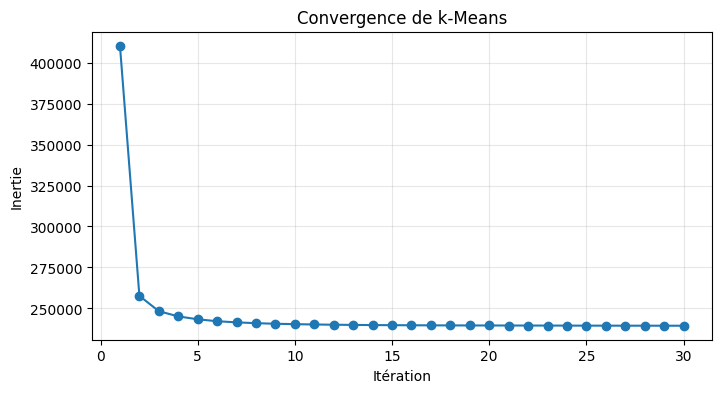

In [3]:

def initialize_kmeans_plus_plus(X, k, random_state=43):
    rng = np.random.default_rng(random_state)
    n, d = X.shape
    if not 0 < k <= n:
        raise ValueError("k doit être compris entre 1 et le nombre d'images.")

    centroids = np.empty((k, d), dtype=X.dtype)
    centroids[0] = X[rng.integers(n)]
    closest_d2 = np.sum((X - centroids[0]) ** 2, axis=1)

    for j in range(1, k):
        total = closest_d2.sum()
        if total <= 0:
            index = rng.integers(n)
        else:
            index = rng.choice(n, p=closest_d2 / total)
        centroids[j] = X[index]
        new_d2 = np.sum((X - centroids[j]) ** 2, axis=1)
        closest_d2 = np.minimum(closest_d2, new_d2)
    return centroids


def squared_distances(X, centroids):
    distances = (
        np.sum(X**2, axis=1, keepdims=True)
        + np.sum(centroids**2, axis=1)
        - 2 * X @ centroids.T
    )
    return np.maximum(distances, 0.0)


def recompute_centroids(X, labels, k, distances):
    new_centroids = np.empty((k, X.shape[1]), dtype=X.dtype)
    min_d2 = distances[np.arange(len(X)), labels]
    for cluster_id in range(k):
        members = X[labels == cluster_id]
        if len(members):
            new_centroids[cluster_id] = members.mean(axis=0)
        else:
            new_centroids[cluster_id] = X[np.argmax(min_d2)]
    return new_centroids

centroids = initialize_kmeans_plus_plus(X_flat, K, SEED)
inertia_history = []
start = time.perf_counter()

for iteration in range(KMEANS_MAX_ITER):
    distances = squared_distances(X_flat, centroids)
    clusters = np.argmin(distances, axis=1)
    inertia = distances[np.arange(len(X_flat)), clusters].sum()
    inertia_history.append(inertia)

    new_centroids = recompute_centroids(X_flat, clusters, K, distances)
    movement = np.linalg.norm(new_centroids - centroids)
    centroids = new_centroids

    print(f"Itération {iteration+1:02d} | inertie={inertia:.2f} | déplacement={movement:.6f}")
    if movement < KMEANS_TOL:
        print("Convergence atteinte.")
        break

# Affectation finale.
distances = squared_distances(X_flat, centroids)
clusters = np.argmin(distances, axis=1)
print("Temps :", round(time.perf_counter() - start, 2), "s")
print("Centroïdes :", centroids.shape)

plt.figure(figsize=(8,4))
plt.plot(range(1, len(inertia_history)+1), inertia_history, marker="o")
plt.xlabel("Itération")
plt.ylabel("Inertie")
plt.title("Convergence de k-Means")
plt.grid(alpha=.3)
plt.show()



## 2.1 Projection des clusters en faible dimension

k-Means ne projette pas directement les données. PCA est utilisée ici uniquement pour afficher les clusters en 2D.


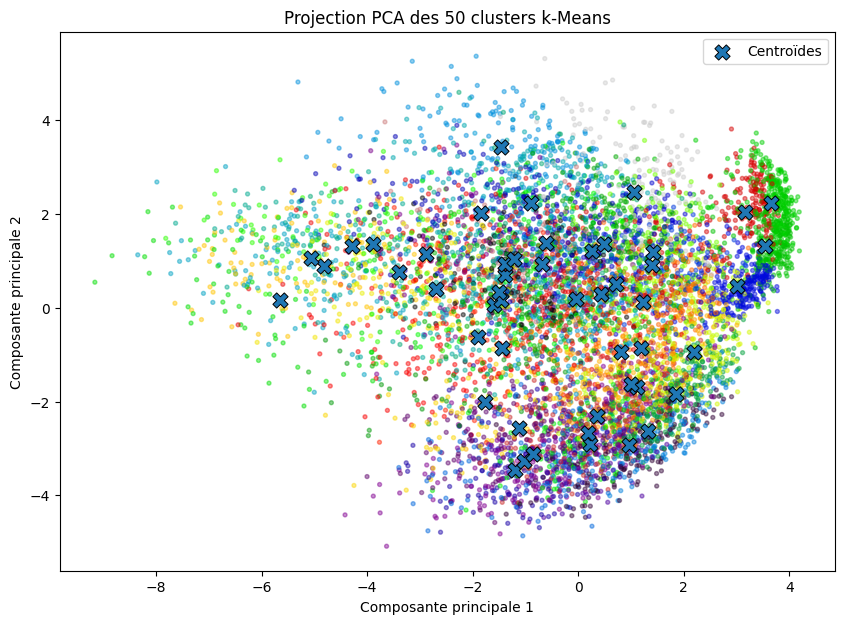

In [4]:

def fit_pca(X, n_components):
    mean = X.mean(axis=0)
    centered = X - mean
    _, singular_values, vt = np.linalg.svd(centered, full_matrices=False)
    variance = singular_values**2 / (len(X)-1)
    return {
        "mean": mean,
        "components": vt[:n_components],
        "explained_variance": variance[:n_components],
        "explained_variance_ratio": variance[:n_components] / variance.sum()
    }


def pca_transform(X, model):
    return (X - model["mean"]) @ model["components"].T


def pca_inverse(Z, model):
    return Z @ model["components"] + model["mean"]

pca_kmeans = fit_pca(X_flat, 2)
X_kmeans_2d = pca_transform(X_flat, pca_kmeans)
centroids_2d = pca_transform(centroids, pca_kmeans)

plt.figure(figsize=(10,7))
plt.scatter(X_kmeans_2d[:,0], X_kmeans_2d[:,1], c=clusters,
            cmap="nipy_spectral", s=8, alpha=.45)
plt.scatter(centroids_2d[:,0], centroids_2d[:,1], marker="X",
            s=120, edgecolors="black", linewidths=.7, label="Centroïdes")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title(f"Projection PCA des {K} clusters k-Means")
plt.legend()
plt.show()



## 2.2 Compression / décompression k-Means

Une image est compressée en conservant uniquement son identifiant de cluster. La décompression remplace cet identifiant par le centroïde correspondant.


Original : (8000, 784)
Compressé : (8000,)
Reconstruit : (8000, 784)
MSE k-Means : 0.03817655


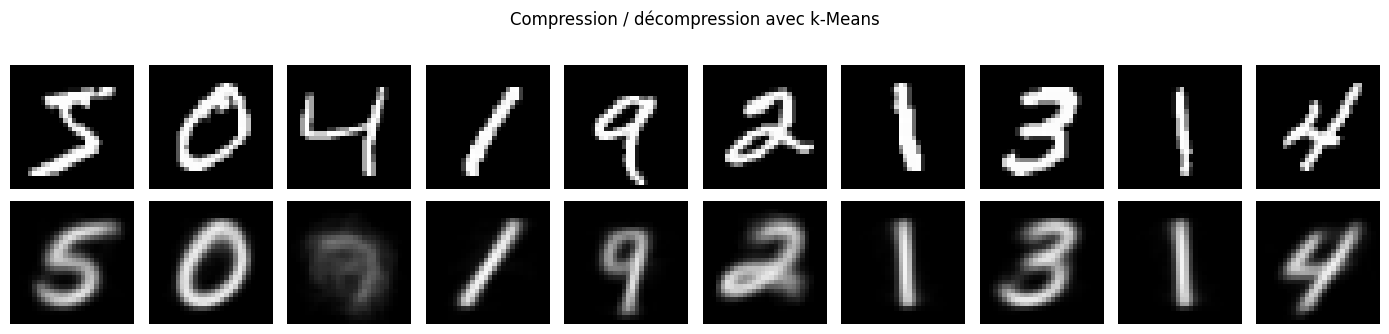

In [5]:

compressed_kmeans = clusters.copy()
reconstructed_kmeans = centroids[compressed_kmeans]
kmeans_mse = np.mean((X_flat - reconstructed_kmeans)**2)

print("Original :", X_flat.shape)
print("Compressé :", compressed_kmeans.shape)
print("Reconstruit :", reconstructed_kmeans.shape)
print("MSE k-Means :", kmeans_mse)

fig, axes = plt.subplots(2, 10, figsize=(14,3.5))
for i in range(10):
    axes[0,i].imshow(X_flat[i].reshape(28,28), cmap="gray", vmin=0, vmax=1)
    axes[1,i].imshow(reconstructed_kmeans[i].reshape(28,28), cmap="gray", vmin=0, vmax=1)
    axes[0,i].axis("off"); axes[1,i].axis("off")
axes[0,0].set_ylabel("Original")
axes[1,0].set_ylabel("Centroïde")
plt.suptitle("Compression / décompression avec k-Means")
plt.tight_layout(); plt.show()



## 2.3 Génération synthétique k-Means

Les centroïdes sont des prototypes synthétiques. On ajoute un bruit proportionnel aux variations observées dans chaque cluster.


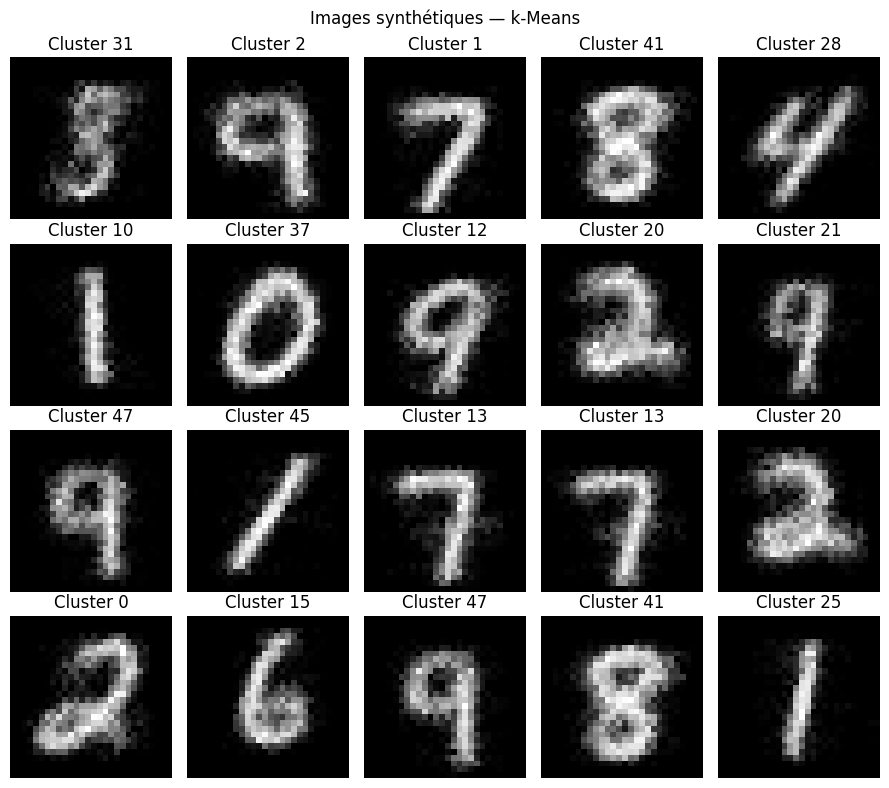

In [6]:

cluster_std = np.zeros_like(centroids)
cluster_sizes = np.zeros(K, dtype=int)
for cluster_id in range(K):
    members = X_flat[clusters == cluster_id]
    cluster_sizes[cluster_id] = len(members)
    if len(members) > 1:
        cluster_std[cluster_id] = members.std(axis=0)

rng = np.random.default_rng(SEED)
chosen_clusters = rng.choice(K, size=20, p=cluster_sizes / cluster_sizes.sum())
generated_kmeans = []
for cluster_id in chosen_clusters:
    noise = rng.normal(0, cluster_std[cluster_id] * .30)
    generated_kmeans.append(np.clip(centroids[cluster_id] + noise, 0, 1))
generated_kmeans = np.array(generated_kmeans)

fig, axes = plt.subplots(4,5, figsize=(9,8))
for image, cluster_id, ax in zip(generated_kmeans, chosen_clusters, axes.ravel()):
    ax.imshow(image.reshape(28,28), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Cluster {cluster_id}")
    ax.axis("off")
plt.suptitle("Images synthétiques — k-Means")
plt.tight_layout(); plt.show()



# 3. PCA / ACP

PCA crée un espace réduit linéaire qui conserve au mieux la variance des données.


## 3.1 Projection PCA en 2D

Avant : (8000, 784)
Après : (8000, 2)
Variance expliquée : 0.17418146


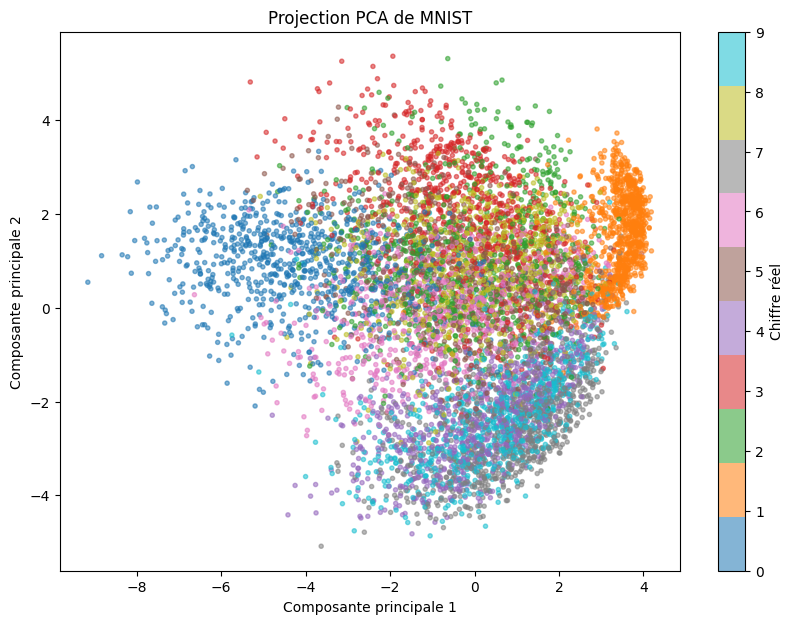

In [7]:

pca_2d = fit_pca(X_flat, 2)
X_pca_2d = pca_transform(X_flat, pca_2d)

print("Avant :", X_flat.shape)
print("Après :", X_pca_2d.shape)
print("Variance expliquée :", pca_2d["explained_variance_ratio"].sum())

plt.figure(figsize=(10,7))
scatter = plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=y,
                      cmap="tab10", s=9, alpha=.55)
plt.colorbar(scatter, ticks=range(10), label="Chiffre réel")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection PCA de MNIST")
plt.show()


## 3.2 Compression / décompression PCA

Original : (8000, 784)
Compressé : (8000, 50)
Facteur de réduction : 15.68
Variance expliquée : 0.82865024
MSE PCA : 0.010040976


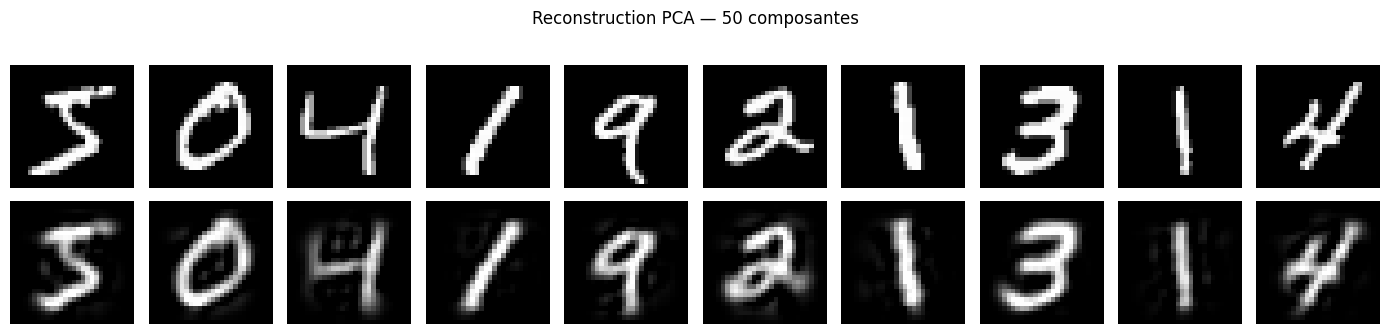

In [8]:

pca_50 = fit_pca(X_flat, PCA_COMPRESSION_COMPONENTS)
compressed_pca = pca_transform(X_flat, pca_50)
reconstructed_pca = np.clip(pca_inverse(compressed_pca, pca_50), 0, 1)
pca_mse = np.mean((X_flat - reconstructed_pca)**2)

print("Original :", X_flat.shape)
print("Compressé :", compressed_pca.shape)
print("Facteur de réduction :", 784 / PCA_COMPRESSION_COMPONENTS)
print("Variance expliquée :", pca_50["explained_variance_ratio"].sum())
print("MSE PCA :", pca_mse)

fig, axes = plt.subplots(2,10, figsize=(14,3.5))
for i in range(10):
    axes[0,i].imshow(X_flat[i].reshape(28,28), cmap="gray", vmin=0, vmax=1)
    axes[1,i].imshow(reconstructed_pca[i].reshape(28,28), cmap="gray", vmin=0, vmax=1)
    axes[0,i].axis("off"); axes[1,i].axis("off")
axes[0,0].set_ylabel("Original")
axes[1,0].set_ylabel("PCA")
plt.suptitle(f"Reconstruction PCA — {PCA_COMPRESSION_COMPONENTS} composantes")
plt.tight_layout(); plt.show()


## 3.3 Génération synthétique PCA

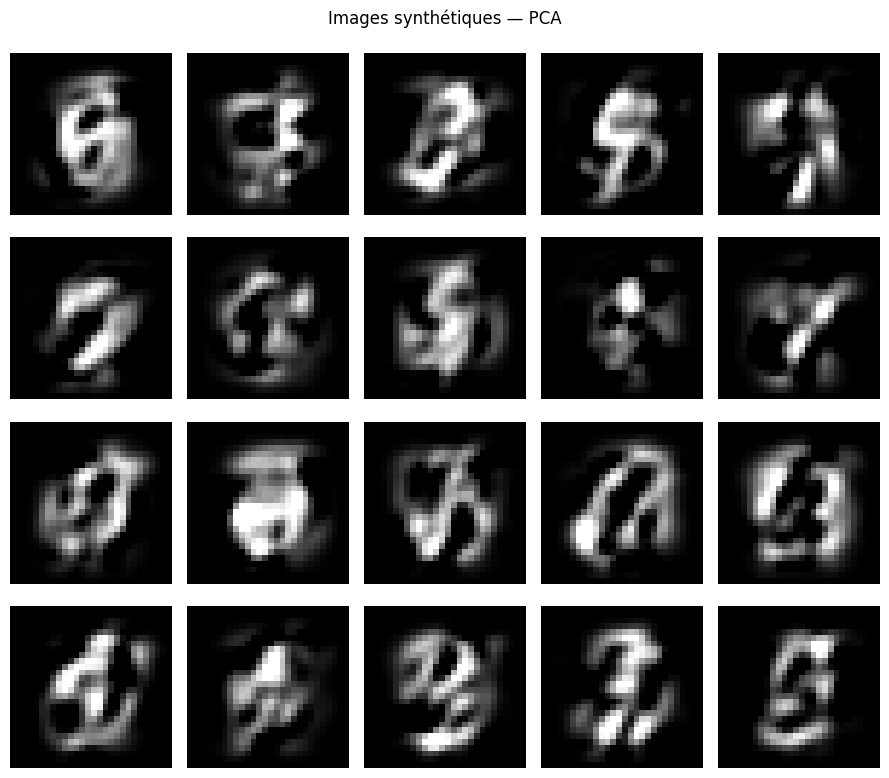

In [9]:

latent_mean = compressed_pca.mean(axis=0)
latent_cov = np.cov(compressed_pca, rowvar=False) + np.eye(PCA_COMPRESSION_COMPONENTS)*1e-6
rng = np.random.default_rng(SEED)
synthetic_codes_pca = rng.multivariate_normal(latent_mean, latent_cov, size=20)
generated_pca = np.clip(pca_inverse(synthetic_codes_pca, pca_50), 0, 1)

fig, axes = plt.subplots(4,5, figsize=(9,8))
for image, ax in zip(generated_pca, axes.ravel()):
    ax.imshow(image.reshape(28,28), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.suptitle("Images synthétiques — PCA")
plt.tight_layout(); plt.show()



# 4. Autoencodeur simple avec TensorFlow/Keras

L’encodeur compresse l’image dans un espace latent. Le décodeur reconstruit l’image à partir de ce code.


In [10]:

split = int(.8 * len(X_flat))
X_ae_train = X_flat[:split]
X_ae_val = X_flat[split:]
y_ae_val = y[split:]


def build_autoencoder(latent_dim):
    inp = Input(shape=(784,), name="image_input")
    x = Dense(256, activation="relu", name="enc_256")(inp)
    x = Dense(64, activation="relu", name="enc_64")(x)
    latent = Dense(latent_dim, activation="linear", name="latent")(x)
    x = Dense(64, activation="relu", name="dec_64")(latent)
    x = Dense(256, activation="relu", name="dec_256")(x)
    out = Dense(784, activation="sigmoid", name="reconstruction")(x)

    autoencoder = Model(inp, out)
    encoder = Model(inp, latent)

    latent_input = Input(shape=(latent_dim,))
    z = autoencoder.get_layer("dec_64")(latent_input)
    z = autoencoder.get_layer("dec_256")(z)
    decoder_output = autoencoder.get_layer("reconstruction")(z)
    decoder = Model(latent_input, decoder_output)

    autoencoder.compile(optimizer=Adam(1e-3), loss="mse")
    return autoencoder, encoder, decoder


def train_autoencoder(latent_dim):
    ae, enc, dec = build_autoencoder(latent_dim)
    callback = EarlyStopping(monitor="val_loss", patience=10,
                             restore_best_weights=True)
    history = ae.fit(
        X_ae_train, X_ae_train,
        validation_data=(X_ae_val, X_ae_val),
        epochs=AE_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=[callback],
        verbose=1
    )
    return ae, enc, dec, history

ae_2, encoder_2, decoder_2, history_2 = train_autoencoder(2)
ae_32, encoder_32, decoder_32, history_32 = train_autoencoder(32)


Epoch 1/100


2026-07-15 13:49:41.286928: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.1316 - val_loss: 0.0716
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0737 - val_loss: 0.0693
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0708 - val_loss: 0.0661
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0672 - val_loss: 0.0635
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0643 - val_loss: 0.0596
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0596 - val_loss: 0.0557
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0566 - val_loss: 0.0541
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0551 - val_loss: 0.0532
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0541 - val_loss: 0.0525
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0533 - val_loss: 0.0520
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0527 - val_loss: 0.0514
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0

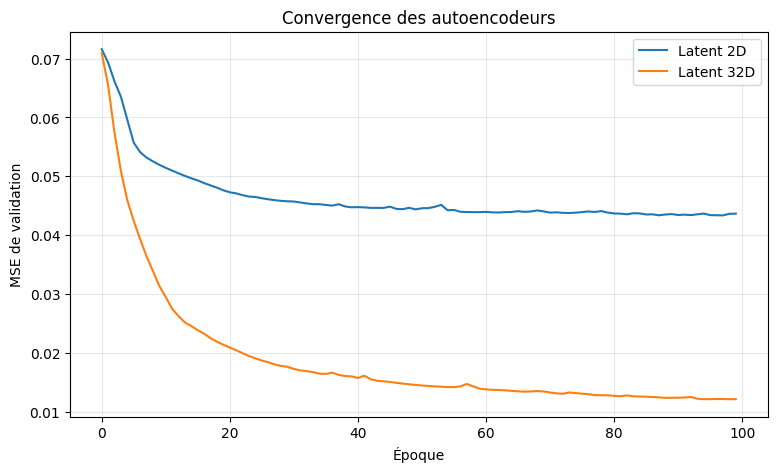

In [11]:

plt.figure(figsize=(9,5))
plt.plot(history_2.history["val_loss"], label="Latent 2D")
plt.plot(history_32.history["val_loss"], label="Latent 32D")
plt.xlabel("Époque")
plt.ylabel("MSE de validation")
plt.title("Convergence des autoencodeurs")
plt.legend(); plt.grid(alpha=.3); plt.show()


## 4.1 Projection dans l’espace latent 2D

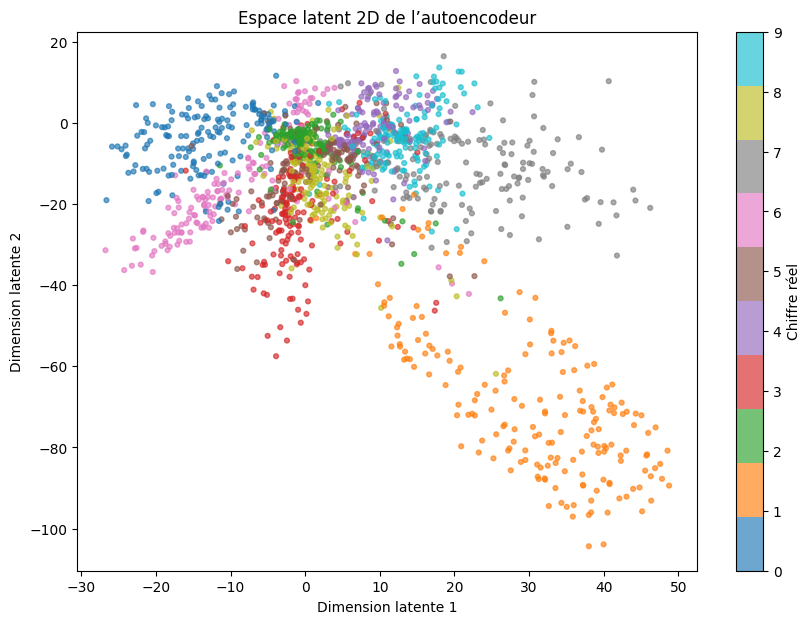

In [12]:

latent_2 = encoder_2.predict(X_ae_val, verbose=0)
plt.figure(figsize=(10,7))
scatter = plt.scatter(latent_2[:,0], latent_2[:,1], c=y_ae_val,
                      cmap="tab10", s=12, alpha=.65)
plt.colorbar(scatter, ticks=range(10), label="Chiffre réel")
plt.xlabel("Dimension latente 1")
plt.ylabel("Dimension latente 2")
plt.title("Espace latent 2D de l’autoencodeur")
plt.show()


## 4.2 Compression / décompression autoencodeur

MSE latent 2D : 0.043380372 | facteur : 392.0
MSE latent 32D : 0.012169751 | facteur : 24.5


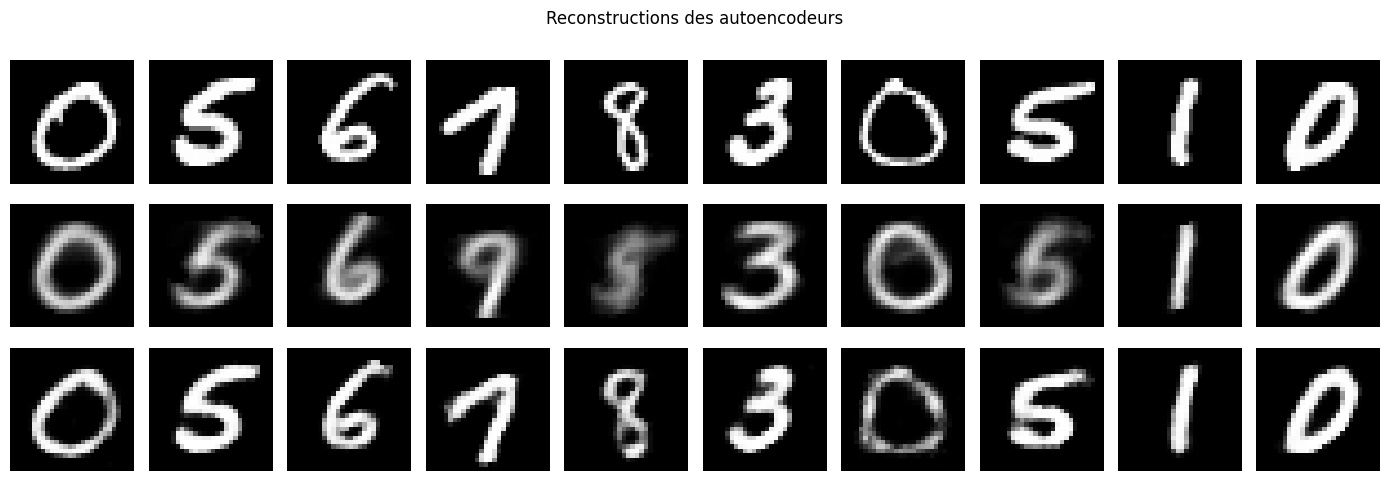

In [13]:

compressed_ae_2 = encoder_2.predict(X_ae_val, verbose=0)
compressed_ae_32 = encoder_32.predict(X_ae_val, verbose=0)
reconstructed_ae_2 = decoder_2.predict(compressed_ae_2, verbose=0)
reconstructed_ae_32 = decoder_32.predict(compressed_ae_32, verbose=0)

ae_mse_2 = np.mean((X_ae_val - reconstructed_ae_2)**2)
ae_mse_32 = np.mean((X_ae_val - reconstructed_ae_32)**2)

print("MSE latent 2D :", ae_mse_2, "| facteur :", 784/2)
print("MSE latent 32D :", ae_mse_32, "| facteur :", 784/32)

fig, axes = plt.subplots(3,10, figsize=(14,5))
for i in range(10):
    axes[0,i].imshow(X_ae_val[i].reshape(28,28), cmap="gray", vmin=0, vmax=1)
    axes[1,i].imshow(reconstructed_ae_2[i].reshape(28,28), cmap="gray", vmin=0, vmax=1)
    axes[2,i].imshow(reconstructed_ae_32[i].reshape(28,28), cmap="gray", vmin=0, vmax=1)
    for row in range(3): axes[row,i].axis("off")
axes[0,0].set_ylabel("Original")
axes[1,0].set_ylabel("Latent 2D")
axes[2,0].set_ylabel("Latent 32D")
plt.suptitle("Reconstructions des autoencodeurs")
plt.tight_layout(); plt.show()


## 4.3 Génération synthétique autoencodeur

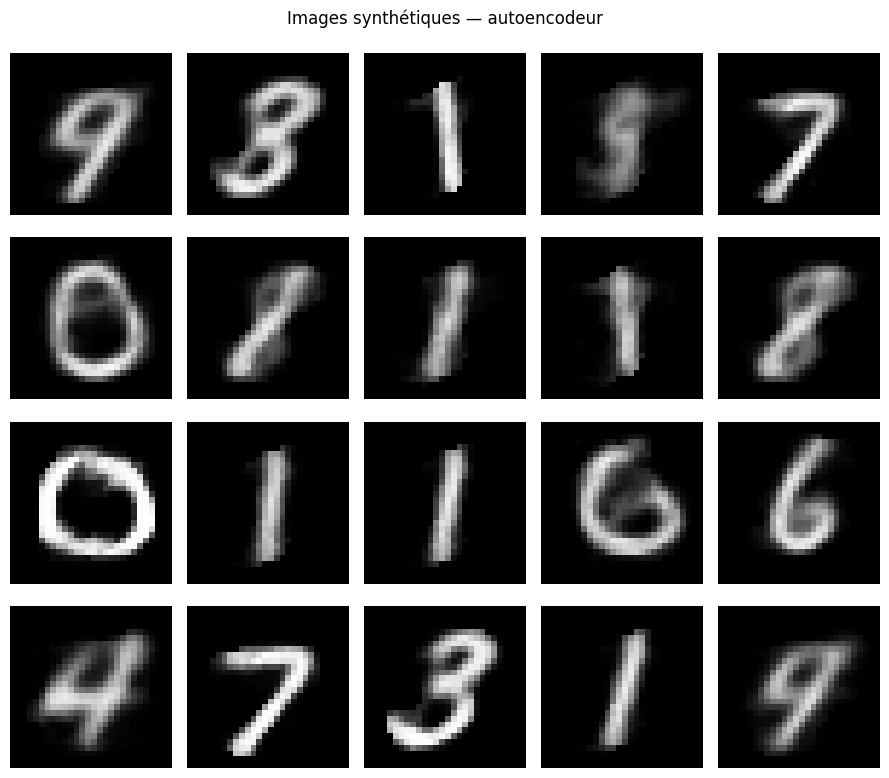

In [14]:

latent_mean_ae = latent_2.mean(axis=0)
latent_cov_ae = np.cov(latent_2, rowvar=False) + np.eye(2)*1e-5
rng = np.random.default_rng(SEED)
synthetic_codes_ae = rng.multivariate_normal(latent_mean_ae, latent_cov_ae, size=20)
generated_ae = decoder_2.predict(synthetic_codes_ae, verbose=0)

fig, axes = plt.subplots(4,5, figsize=(9,8))
for image, ax in zip(generated_ae, axes.ravel()):
    ax.imshow(image.reshape(28,28), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.suptitle("Images synthétiques — autoencodeur")
plt.tight_layout(); plt.show()


# 5. Comparaison finale

In [15]:

comparison = pd.DataFrame({
    "Méthode": [
        f"k-Means ({K} clusters)",
        f"PCA ({PCA_COMPRESSION_COMPONENTS} composantes)",
        "Autoencodeur latent 2D",
        "Autoencodeur latent 32D"
    ],
    "Dimension compressée": [1, PCA_COMPRESSION_COMPONENTS, 2, 32],
    "MSE de reconstruction": [kmeans_mse, pca_mse, ae_mse_2, ae_mse_32]
})
comparison


,Méthode,Dimension compressée,MSE de reconstruction
0,k-Means (50 clusters),1,0.038177
1,PCA (50 composantes),50,0.010041
2,Autoencodeur latent 2D,2,0.043380
3,Autoencodeur latent 32D,32,0.012170


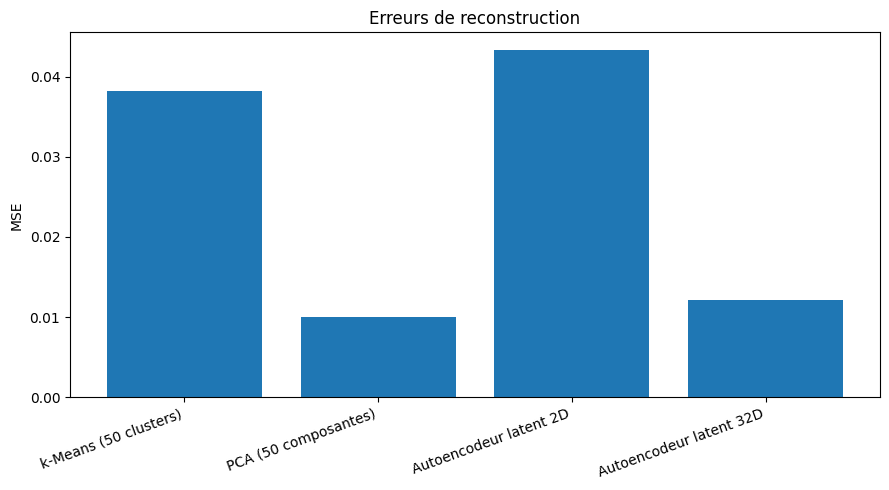

In [16]:

plt.figure(figsize=(9,5))
plt.bar(comparison["Méthode"], comparison["MSE de reconstruction"])
plt.ylabel("MSE")
plt.title("Erreurs de reconstruction")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()



# Conclusion

- **k-Means** est surtout adapté au regroupement. Sa compression est très forte, mais la reconstruction et la génération sont rudimentaires.
- **PCA** est directement adaptée à la projection et à la compression. Elle reste limitée aux relations linéaires.
- **L’autoencodeur** apprend une représentation non linéaire. Il permet la compression, la reconstruction et une génération simple à partir de l’espace latent.
- Pour une génération plus fiable, un **autoencodeur variationnel (VAE)** serait mieux adapté qu’un autoencodeur simple.
